# Outpatient Resource Allocation and Turnaround Time

This notebook defines a synthetic planning problem for an outpatient treatment
unit (for example chemotherapy / infusion) and solves it with **PyGuLP**.

The example is designed to exercise:

- integer **resource variables** (staff allocations),
- **derived performance variables** (average turnaround time, TAT),
- **binary configuration decisions** (template selection, overflow capacity),
- multiple, potentially conflicting **goals** (TAT, access, and a secondary cost term).

The structure goes beyond a simple waiting-time example by linking staffing to TAT
and mixing discrete configuration choices with continuous access decisions.

## Literature sources

- https://onlinelibrary.wiley.com/doi/10.1155/2013/680152
- https://www.sciencedirect.com/science/article/pii/S2211692316301291
- https://or.stackexchange.com/questions/6454/need-help-with-an-appointment-scheduling-problem
- https://repositorio.uac.pt/bitstreams/5edbaa77-2aa3-40e8-9022-4345df22f7e3/download


In [1]:

import pandas as pd

# ---------------------------------------------
# 1. Service units inside the outpatient system
# ---------------------------------------------

units = pd.DataFrame({
    "Unit": ["Triage", "Consultation", "Infusion"],
    "Staff_Type": ["Nurse", "Doctor", "Nurse"],
    # Feasible staff bounds for a single planning day
    "Min_Staff": [1, 1, 2],
    "Max_Staff": [3, 4, 5],
    # Cost per staff-hour in arbitrary units
    "Staff_Cost_per_Hour": [20.0, 80.0, 25.0],
})

# ---------------------------------------------
# 2. Patient classes
# ---------------------------------------------
# Each class follows the same Triage → Consultation → Infusion structure,
# but with different volumes and baseline TAT.

patient_classes = pd.DataFrame({
    "Class": ["Chemo_Long", "Chemo_Short", "Followup"],
    # Expected arrivals per planning day
    "Daily_Volume": [10, 20, 30],
    # Baseline average turnaround time (minutes) under Min_Staff
    "Base_TAT": [360.0, 240.0, 120.0],
    # Service-level targets on TAT (minutes)
    "TAT_Target": [270.0, 180.0, 90.0],
    # Priority weights to reflect clinical / managerial importance
    "Priority_Weight": [3.0, 2.0, 1.0],
})

# ---------------------------------------------
# 3. TAT sensitivity to staffing by unit
# ---------------------------------------------
# Linear surrogate: for each extra staff member above Min_Staff,
# TAT for class c is reduced by Gamma minutes at that unit.

tat_sensitivity = pd.DataFrame({
    "Class": ["Chemo_Long"] * 3 + ["Chemo_Short"] * 3 + ["Followup"] * 3,
    "Unit":  ["Triage", "Consultation", "Infusion"] * 3,
    # Minutes of TAT reduction per extra staff member in that unit
    "Gamma": [
        3.0, 10.0, 12.0,   # Chemo_Long
        1.0, 6.0,  6.0,    # Chemo_Short
        0.5, 3.0,  2.0,    # Followup
    ],
})

# ---------------------------------------------
# 4. Discrete configuration options (for binary decisions)
# ---------------------------------------------
# These are "bundle" decisions that should be modelled with binary variables:
#   - Exactly one infusion scheduling template must be chosen.
#   - Overflow beds can optionally be opened.

config_options = pd.DataFrame({
    "Option_ID": [
        "INF_TEMPLATE_BASE",
        "INF_TEMPLATE_EXTENDED",
        "INF_OVERFLOW_BEDS",
    ],
    # Type groups options that compete or interact
    "Option_Type": [
        "Infusion_Template",
        "Infusion_Template",
        "Capacity_AddOn",
    ],
    "Description": [
        "Baseline infusion day: 8-hour day, standard chair schedule.",
        "Extended infusion day: 10-hour day, more evenly spread starts.",
        "Open 2 overflow infusion beds for the day.",
    ],
    # Additional nurse-hours required by this option
    "Extra_Nurse_Hours": [
        0.0,   # baseline
        8.0,   # one extra nurse for 8 hours
        4.0,   # additional monitoring time for overflow beds
    ],
    # Additional fixed cost of activating this option (per day)
    "Fixed_Cost": [
        0.0,
        400.0,
        200.0,
    ],
    # Approximate multiplicative factor on effective infusion capacity
    "Infusion_Capacity_Factor": [
        1.00,   # baseline
        1.25,
        1.10,
    ],
})

# ---------------------------------------------
# 5. Global planning parameters
# ---------------------------------------------

global_params = {
    # Baseline planning horizon in hours
    "Base_Hours_Per_Day": 8.0,
    # Budget cap for staff cost + fixed option costs (optional)
    "Max_Daily_Budget": 6000.0,
    # Minimum fraction of each class that should be treated in a day
    # (can be used for access / fairness constraints)
    "Min_Service_Prop": {
        "Chemo_Long": 0.6,
        "Chemo_Short": 0.5,
        "Followup": 0.4,
    },
}

units, patient_classes, tat_sensitivity, config_options, global_params


(           Unit Staff_Type  Min_Staff  Max_Staff  Staff_Cost_per_Hour
 0        Triage      Nurse          1          3                 20.0
 1  Consultation     Doctor          1          4                 80.0
 2      Infusion      Nurse          2          5                 25.0,
          Class  Daily_Volume  Base_TAT  TAT_Target  Priority_Weight
 0   Chemo_Long            10     360.0       270.0              3.0
 1  Chemo_Short            20     240.0       180.0              2.0
 2     Followup            30     120.0        90.0              1.0,
          Class          Unit  Gamma
 0   Chemo_Long        Triage    3.0
 1   Chemo_Long  Consultation   10.0
 2   Chemo_Long      Infusion   12.0
 3  Chemo_Short        Triage    1.0
 4  Chemo_Short  Consultation    6.0
 5  Chemo_Short      Infusion    6.0
 6     Followup        Triage    0.5
 7     Followup  Consultation    3.0
 8     Followup      Infusion    2.0,
                Option_ID        Option_Type  \
 0      INF_TEMPLAT


## Data Structures and Column Descriptions

### `units` – service stages and staffing parameters

Columns:

- **`Unit`**  
  Logical stage of the outpatient flow. All patient classes are assumed to pass through all units in sequence (e.g., Triage → Consultation → Infusion).

- **`Staff_Type`**  
  Dominant staff category driving capacity at the unit (e.g., nurses in triage and infusion, physicians in consultation). Used for cost accounting and possible skill-mix extensions.

- **`Min_Staff`, `Max_Staff`**  
  Lower and upper bounds on the number of staff assigned to the unit for the planning day. These induce box constraints on staffing decision variables.

- **`Staff_Cost_per_Hour`**  
  Cost per staff-hour at that unit, used to construct daily staffing cost expressions such as.

---

### `patient_classes` – demand and TAT targets

Columns:

- **`Class`**  
  Aggregate patient category (e.g., long vs short chemotherapy protocols, follow-up visits).

- **`Daily_Volume`**  
  Expected number of arrivals of that class during the planning day.

- **`Base_TAT`**  
  Baseline average turnaround time (minutes) for the class when each unit operates at its `Min_Staff` level. Used as a reference in the linear TAT approximation.

- **`TAT_Target`**  
  Service-level target for average TAT (minutes) for the class. Natural target for TAT-related GLP goals.

- **`Priority_Weight`**  
  Relative importance of meeting the TAT target for this class. Can be used as the weight in a goal on `TAT_c` or in a multi-objective objective function.

---

### `tat_sensitivity` – linear TAT reduction per extra staff

Columns:

- **`Class`** / **`Unit`**  
  Identify the class–unit pair for which a sensitivity parameter is specified.

- **`Gamma`**  
  Minutes of TAT reduction per additional staff member at unit for class, relative to `Min_Staff`.  
  A typical surrogate is:  
This provides a deterministic linear proxy for the queueing effects described in resource-allocation and simulation-based appointment scheduling papers.

---

### `config_options` – discrete configuration options

Columns:

- **`Option_ID`**  
  Identifier for a configuration option. Intended to map one-to-one with a binary decision variable \(z_k \in \{0,1\}\).

- **`Option_Type`**    
Logical grouping of mutually exclusive options. For Infusion_Template, exactly one template should be selected; Capacity_AddOn options can be modelled as independent on/off decisions.

- **`Extra_Nurse_Hours`**  
  Additional nurse-hours required if the option is activated.

- **`Fixed_Cost`**  
  Fixed daily cost of activating the option (e.g., overheads for extended opening hours or using overflow beds). Introduces fixed-charge effects.

- **`Infusion_Capacity_Factor`**  
  Multiplicative factor on effective infusion capacity when the option is active. For instance, a factor of 1.25 implies a 25% increase in infusion capacity relative to the baseline.

---

### `global_params` – global planning parameters

Keys:

- **`Base_Hours_Per_Day`**  
  Baseline planning horizon in hours, used to convert staff counts at each unit into staff-hours for cost calculations.

- **`Max_Daily_Budget`**  
  Optional budget cap for total daily cost (staffing plus fixed configuration costs).

- **`Min_Service_Prop`**  
  Dictionary mapping each class to a minimum fraction of its daily volume that should be treated.

In [2]:

print("Units:")
display(units)
print("\nPatient classes:")
display(patient_classes)
print("\nTAT sensitivity:")
display(tat_sensitivity)
print("\nConfiguration options:")
display(config_options)
print("\nGlobal parameters:")
display(global_params)


Units:


,Unit,Staff_Type,Min_Staff,Max_Staff,Staff_Cost_per_Hour
0,Triage,Nurse,1,3,20.0
1,Consultation,Doctor,1,4,80.0
2,Infusion,Nurse,2,5,25.0



Patient classes:


,Class,Daily_Volume,Base_TAT,TAT_Target,Priority_Weight
0,Chemo_Long,10,360.0,270.0,3.0
1,Chemo_Short,20,240.0,180.0,2.0
2,Followup,30,120.0,90.0,1.0



TAT sensitivity:


,Class,Unit,Gamma
0,Chemo_Long,Triage,3.0
1,Chemo_Long,Consultation,10.0
2,Chemo_Long,Infusion,12.0
3,Chemo_Short,Triage,1.0
4,Chemo_Short,Consultation,6.0
5,Chemo_Short,Infusion,6.0
6,Followup,Triage,0.5
7,Followup,Consultation,3.0
8,Followup,Infusion,2.0



Configuration options:


,Option_ID,Option_Type,Description,Extra_Nurse_Hours,Fixed_Cost,Infusion_Capacity_Factor
0,INF_TEMPLATE_BASE,Infusion_Template,"Baseline infusion day: 8-hour day, standard ch...",0.0,0.0,1.00
1,INF_TEMPLATE_EXTENDED,Infusion_Template,"Extended infusion day: 10-hour day, more evenl...",8.0,400.0,1.25
2,INF_OVERFLOW_BEDS,Capacity_AddOn,Open 2 overflow infusion beds for the day.,4.0,200.0,1.10



Global parameters:


{'Base_Hours_Per_Day': 8.0,
 'Max_Daily_Budget': 6000.0,
 'Min_Service_Prop': {'Chemo_Long': 0.6, 'Chemo_Short': 0.5, 'Followup': 0.4}}

## Goal-programming formulation

The remainder of the notebook builds a weighted goal program with
`GLPModel`. Hard constraints must be satisfied; goals are allowed to miss
their targets, and the solver penalizes selected deviations.

Decision variables:

- $x_u$: staff assigned to unit $u$ (integer, boxed by `Min_Staff` / `Max_Staff`)
- $z_k$: whether configuration option $k$ is selected (binary)
- $p_c$: fraction of class $c$ served during the day
- $\mathrm{TAT}_c$: average turnaround time for class $c$ (minutes)

Hard constraints:

- TAT is a linear function of extra staff above the minimum
- exactly one infusion template is chosen
- total cost cannot exceed the daily budget
- served volume cannot exceed infusion capacity

Goals:

- keep TAT at or below the class target (penalize overruns only)
- push the served fraction toward 1 (penalize shortfalls only)
- a small cost term breaks ties toward cheaper plans


## Index lookups

Convert the tables into dictionaries so the algebraic expressions stay compact.
The `gamma` lookup is the minutes of TAT reduced for class $c$ by one extra staff
member at unit $u$. Infusion templates are the mutually exclusive options in
`config_options`; overflow beds are an independent on/off add-on.

`patients_per_nurse_hour` is a simple capacity rate: each effective infusion
nurse-hour can treat two patients.


In [3]:
import pulp

from pygulp.constraint import Constraint
from pygulp.core import GLPModel
from pygulp.enums import ConstraintSense
from pygulp.goal import Goal

U = units["Unit"].tolist()
C = patient_classes["Class"].tolist()
K = config_options["Option_ID"].tolist()

min_staff = units.set_index("Unit")["Min_Staff"].to_dict()
max_staff = units.set_index("Unit")["Max_Staff"].to_dict()
staff_cost = units.set_index("Unit")["Staff_Cost_per_Hour"].to_dict()

base_tat = patient_classes.set_index("Class")["Base_TAT"].to_dict()
tat_target = patient_classes.set_index("Class")["TAT_Target"].to_dict()
priority = patient_classes.set_index("Class")["Priority_Weight"].to_dict()
daily_vol = patient_classes.set_index("Class")["Daily_Volume"].to_dict()

gamma = tat_sensitivity.set_index(["Class", "Unit"])["Gamma"].to_dict()

opt_type = config_options.set_index("Option_ID")["Option_Type"].to_dict()
opt_fixed = config_options.set_index("Option_ID")["Fixed_Cost"].to_dict()
opt_extra_nurse_hours = config_options.set_index("Option_ID")[
    "Extra_Nurse_Hours"
].to_dict()

base_hours = float(global_params["Base_Hours_Per_Day"])
budget = float(global_params["Max_Daily_Budget"])
min_service_prop = global_params["Min_Service_Prop"]

infusion_nurse_cost = staff_cost["Infusion"]
templates = [k for k in K if opt_type[k] == "Infusion_Template"]

# Capacity assumption: patients treated per infusion nurse-hour
patients_per_nurse_hour = 2.0

print("Units:", U)
print("Classes:", C)
print("Options:", K)
print("Infusion templates:", templates)


Units: ['Triage', 'Consultation', 'Infusion']
Classes: ['Chemo_Long', 'Chemo_Short', 'Followup']
Options: ['INF_TEMPLATE_BASE', 'INF_TEMPLATE_EXTENDED', 'INF_OVERFLOW_BEDS']
Infusion templates: ['INF_TEMPLATE_BASE', 'INF_TEMPLATE_EXTENDED']


## Decision variables

Create a `GLPModel` and register the four families of variables.

Staff counts are integer and already boxed by the unit bounds. Configuration
options are binary. Service proportions are continuous, with a lower bound from
`Min_Service_Prop` so a minimum access level is a hard constraint, not a goal.
TAT variables are non-negative and will be tied to staffing in the next section.


In [4]:
m = GLPModel(name="Outpatient_GLPP", minimize=True)

x = {
    u: m.add_variable(
        f"x_staff_{u}",
        low_bound=min_staff[u],
        up_bound=max_staff[u],
        cat="Integer",
    )
    for u in U
}

z = {
    k: m.add_variable(f"z_{k}", low_bound=0, up_bound=1, cat="Binary")
    for k in K
}

p = {
    c: m.add_variable(
        f"p_service_{c}",
        low_bound=min_service_prop[c],
        up_bound=1,
        cat="Continuous",
    )
    for c in C
}

TAT = {
    c: m.add_variable(f"TAT_{c}", low_bound=0, cat="Continuous") for c in C
}

m


GLPModel(vars=12, goals=0, groups=0)

## Hard constraints

**TAT linkage.** At minimum staffing, class $c$ has turnaround $\mathrm{BaseTAT}_c$.
Each extra staff member at unit $u$ reduces that TAT by $\Gamma_{c,u}$:

$$
\mathrm{TAT}_c = \mathrm{BaseTAT}_c - \sum_u \Gamma_{c,u}(x_u - \mathrm{MinStaff}_u)
$$

**Template selection.** Exactly one infusion-day template must be chosen.

**Cost and budget.** Daily cost is staff-hours plus option fixed costs plus extra
infusion-nurse hours. That total cannot exceed `Max_Daily_Budget`.

**Infusion capacity.** Served patients cannot exceed two patients per
effective infusion nurse-hour over the planning horizon. Extra nurse-hours
from selected options are converted back into equivalent staff.


In [5]:
# TAT_c = Base_TAT_c - sum_u Gamma[c, u] * (x_u - MinStaff_u)
for c in C:
    tat_link_expr = (
        TAT[c]
        - base_tat[c]
        + pulp.lpSum(
            gamma.get((c, u), 0.0) * (x[u] - min_staff[u]) for u in U
        )
    )
    m.add_constraint(
        Constraint(
            name=f"link_TAT_{c}",
            expression=tat_link_expr,
            sense=ConstraintSense.EQ,
            rhs=0.0,
        )
    )

m.add_constraint(
    Constraint(
        name="one_infusion_template",
        expression=pulp.lpSum(z[k] for k in templates),
        sense=ConstraintSense.EQ,
        rhs=1.0,
    )
)

staff_hours_cost = pulp.lpSum(staff_cost[u] * x[u] * base_hours for u in U)
fixed_option_cost = pulp.lpSum(opt_fixed[k] * z[k] for k in K)
extra_nurse_cost = pulp.lpSum(
    opt_extra_nurse_hours[k] * infusion_nurse_cost * z[k] for k in K
)
total_cost_expr = staff_hours_cost + fixed_option_cost + extra_nurse_cost

m.add_constraint(
    Constraint(
        name="budget_cap",
        expression=total_cost_expr,
        sense=ConstraintSense.LE,
        rhs=budget,
    )
)

served_patients = pulp.lpSum(p[c] * daily_vol[c] for c in C)
effective_infusion_staff = x["Infusion"] + pulp.lpSum(
    (opt_extra_nurse_hours[k] / base_hours) * z[k] for k in K
)
capacity_expr = (
    served_patients
    - patients_per_nurse_hour * base_hours * effective_infusion_staff
)
m.add_constraint(
    Constraint(
        name="infusion_capacity",
        expression=capacity_expr,
        sense=ConstraintSense.LE,
        rhs=0.0,
    )
)

print("Constraints:", list(m.constraints))


Constraints: ['link_TAT_Chemo_Long', 'link_TAT_Chemo_Short', 'link_TAT_Followup', 'one_infusion_template', 'budget_cap', 'infusion_capacity']


## Goals

PyGuLP links each goal as $\mathrm{expression} + n - p = \mathrm{target}$, then
penalizes the chosen deviation variables.

- **TAT goals:** the target is a service-level ceiling. Only the positive
  deviation $p$ is weighted, so finishing *faster* than the target is free.
  The class `Priority_Weight` is the overrun penalty.
- **Access goals:** the target is full service ($p_c = 1$). Only the negative
  deviation $n$ is weighted, so serving *more* than 100% is not rewarded and
  is already forbidden by the variable upper bound.

A small cost weight ($10^{-3}$) is applied later so that, among plans with the
same goal deviations, cheaper ones are preferred.


In [6]:
goal_weights = {}

for c in C:
    m.add_goal(
        Goal(
            name=f"TAT_target_{c}",
            expression=TAT[c],
            target=tat_target[c],
            weight=priority[c],
        )
    )
    # (under-achievement weight, over-achievement weight)
    goal_weights[f"TAT_target_{c}"] = (0.0, priority[c])

lambda_access = 1.0
for c in C:
    m.add_goal(
        Goal(
            name=f"Access_{c}",
            expression=p[c],
            target=1.0,
            weight=lambda_access * priority[c],
        )
    )
    goal_weights[f"Access_{c}"] = (lambda_access * priority[c], 0.0)

pd.DataFrame(
    [
        {
            "goal": name,
            "weight_under": w_minus,
            "weight_over": w_plus,
        }
        for name, (w_minus, w_plus) in goal_weights.items()
    ]
)


,goal,weight_under,weight_over
0,TAT_target_Chemo_Long,0.0,3.0
1,TAT_target_Chemo_Short,0.0,2.0
2,TAT_target_Followup,0.0,1.0
3,Access_Chemo_Long,3.0,0.0
4,Access_Chemo_Short,2.0,0.0
5,Access_Followup,1.0,0.0


## Solve

`solve_weighted` minimises

$$
\lambda_{\mathrm{cost}}\,\mathrm{Cost}
+ \sum_i \left(w_i^- n_i + w_i^+ p_i\right)
$$

with CBC (the default PuLP solver). `goal_weights` overrides the default
two-sided penalty so TAT overruns and access shortfalls are one-sided.


In [7]:
lambda_cost = 1e-3
result = m.solve_weighted(
    goal_weights=goal_weights,
    cost_expr=total_cost_expr,
    cost_weight=lambda_cost,
)

print("Status:", result["status"])
print(f"Objective value: {result['objective']:.4f}")


Status: Optimal
Objective value: 116.0400


## Results

Staffing, selected options, class-level TAT/access, and a capacity check are
reconstructed from the `variables` and `deviations` entries of `result`.
Deviation tuples are $(n, p)$: under-achievement then over-achievement.


In [8]:
staff_hours_cost_val = sum(
    staff_cost[u] * result["variables"][f"x_staff_{u}"] * base_hours for u in U
)
fixed_option_cost_val = sum(
    opt_fixed[k] * result["variables"][f"z_{k}"] for k in K
)
extra_nurse_cost_val = sum(
    opt_extra_nurse_hours[k]
    * infusion_nurse_cost
    * result["variables"][f"z_{k}"]
    for k in K
)
total_cost_val = (
    staff_hours_cost_val + fixed_option_cost_val + extra_nurse_cost_val
)

staffing = pd.DataFrame(
    {
        "Unit": U,
        "Staff": [result["variables"][f"x_staff_{u}"] for u in U],
        "Min": [min_staff[u] for u in U],
        "Max": [max_staff[u] for u in U],
    }
)

options = pd.DataFrame(
    {
        "Option_ID": K,
        "Selected": [
            int((result["variables"][f"z_{k}"] or 0) > 0.5) for k in K
        ],
        "Option_Type": [opt_type[k] for k in K],
        "Fixed_Cost": [opt_fixed[k] for k in K],
    }
)

outcomes = pd.DataFrame(
    {
        "Class": C,
        "Service_Prop": [result["variables"][f"p_service_{c}"] for c in C],
        "Served": [
            result["variables"][f"p_service_{c}"] * daily_vol[c] for c in C
        ],
        "TAT": [result["variables"][f"TAT_{c}"] for c in C],
        "TAT_Target": [tat_target[c] for c in C],
        "TAT_Overrun": [
            result["deviations"][f"TAT_target_{c}"][1] for c in C
        ],
        "Access_Shortfall": [
            result["deviations"][f"Access_{c}"][0] for c in C
        ],
    }
)

served_total = sum(
    result["variables"][f"p_service_{c}"] * daily_vol[c] for c in C
)
effective_staff_val = result["variables"]["x_staff_Infusion"] + sum(
    (opt_extra_nurse_hours[k] / base_hours) * result["variables"][f"z_{k}"]
    for k in K
)
capacity_rhs = patients_per_nurse_hour * base_hours * effective_staff_val

print(f"Total cost: {total_cost_val:.2f} (budget {budget:.2f})")
print(f"Served patients: {served_total:.2f}")
print(f"Effective infusion staff: {effective_staff_val:.2f}")
print(f"Infusion capacity: {capacity_rhs:.2f}")

display(staffing)
display(options)
display(outcomes)


Total cost: 4040.00 (budget 6000.00)
Served patients: 60.00
Effective infusion staff: 5.00
Infusion capacity: 80.00


,Unit,Staff,Min,Max
0,Triage,3.0,1,3
1,Consultation,4.0,1,4
2,Infusion,5.0,2,5


,Option_ID,Selected,Option_Type,Fixed_Cost
0,INF_TEMPLATE_BASE,1,Infusion_Template,0.0
1,INF_TEMPLATE_EXTENDED,0,Infusion_Template,400.0
2,INF_OVERFLOW_BEDS,0,Capacity_AddOn,200.0


,Class,Service_Prop,Served,TAT,TAT_Target,TAT_Overrun,Access_Shortfall
0,Chemo_Long,1.0,10.0,288.0,270.0,18.0,0.0
1,Chemo_Short,1.0,20.0,202.0,180.0,22.0,0.0
2,Followup,1.0,30.0,104.0,90.0,14.0,0.0


## Visual comparison

The left panel compares achieved TAT with the class target. The right panel
shows the served fraction against the hard minimum and the access goal of 1.


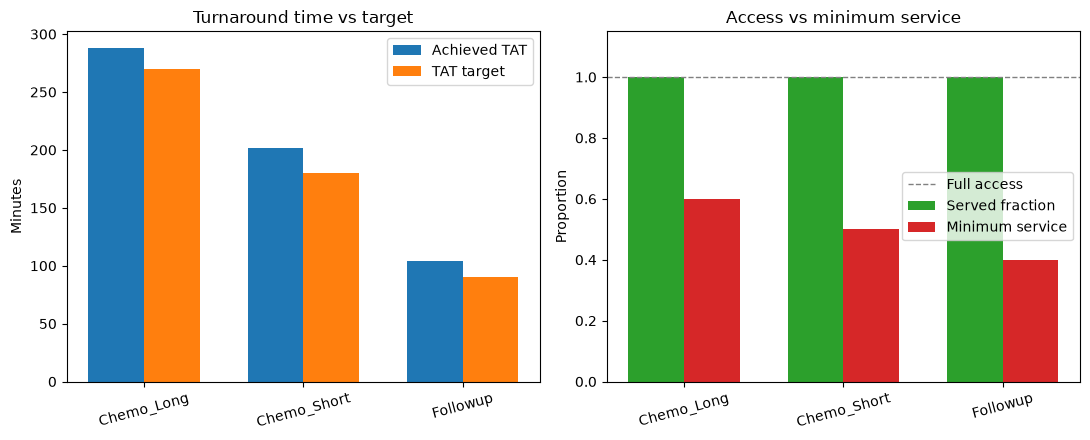

In [9]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

x_pos = np.arange(len(C))
width = 0.35
axes[0].bar(
    x_pos - width / 2,
    outcomes["TAT"],
    width,
    label="Achieved TAT",
    color="#1f77b4",
)
axes[0].bar(
    x_pos + width / 2,
    outcomes["TAT_Target"],
    width,
    label="TAT target",
    color="#ff7f0e",
)
axes[0].set_xticks(x_pos, C, rotation=15)
axes[0].set_ylabel("Minutes")
axes[0].set_title("Turnaround time vs target")
axes[0].legend()

axes[1].bar(
    x_pos - width / 2,
    outcomes["Service_Prop"],
    width,
    label="Served fraction",
    color="#2ca02c",
)
axes[1].bar(
    x_pos + width / 2,
    [min_service_prop[c] for c in C],
    width,
    label="Minimum service",
    color="#d62728",
)
axes[1].axhline(1.0, color="gray", linestyle="--", linewidth=1, label="Full access")
axes[1].set_xticks(x_pos, C, rotation=15)
axes[1].set_ylabel("Proportion")
axes[1].set_ylim(0, 1.15)
axes[1].set_title("Access vs minimum service")
axes[1].legend()

fig.tight_layout()
plt.show()


## Reading the solution

The model is a weighted goal program, not a single-objective cost minimiser.
CBC reports **Optimal** for the weighted objective; that does not mean every
TAT and access target is met.

Inspect `TAT_Overrun` and `Access_Shortfall` in the outcomes table:

- a zero TAT overrun means that class is at or below its service-level target
- a positive access shortfall means some of that class is left unserved,
  even though the hard `Min_Service_Prop` floor is still respected
- the selected $z_k$ row shows which infusion template (and whether overflow
  beds) the solver used to support that staffing/access mix
